In [1]:
#This bit of code allows me to output more than one variable value without using a print statement.
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import pandas as pd

df = pd.read_csv('charity_data.csv')

#Target Variable Exploration
#TRUE = FAILED (not registered)
#FALSE = SURVIVED
#NaN = MISSING (Intentional)

class_counts = df["Class"].value_counts(dropna=False)
print("Class counts:\n", class_counts)

#Percent breakdown (including missing)
class_percent = df["Class"].value_counts(dropna=False, normalize=True) * 100
print("\nClass % :\n", class_percent.round(2))

#Failure rate among labeled rows only- here we are ignoring NaN labels
labeled = df[df["Class"].notna()]
failure_rate = labeled["Class"].mean()  
print("\nFailure rate among labeled rows:", round(float(failure_rate), 4))
print("Labeled rows:", labeled.shape[0], ". Unlabeled rows:", df["Class"].isna().sum())


#quantify 'missingness' across all variables aka see how much is missing in each variable 
missing_counts = df.isna().sum()
missing_pct = (df.isna().mean() * 100)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_pct.round(2)})
print(missing_summary)







Class counts:
 Class
False    52067
NaN      13778
True      3042
Name: count, dtype: int64

Class % :
 Class
False    75.58
NaN      20.00
True      4.42
Name: proportion, dtype: float64

Failure rate among labeled rows: 0.0552
Labeled rows: 55109 . Unlabeled rows: 13778
                                       missing_count  missing_percent
Unnamed: 0                                         0             0.00
Class                                          13778            20.00
BN                                                 0             0.00
Designation                                        0             0.00
Category                                           0             0.00
Legal Name                                         0             0.00
City                                               0             0.00
Province                                           0             0.00
Postal Code                                        0             0.00
Charity_Internal_Division  

In [3]:
#Internal ratio (POTENTIALS) Log_Total_Revenue, Log_Total_Assets, Debt_Ratio, Cateogry, Fundraising Dependence

#CLEAN AND CREATE INTERNAL FEATURES
import numpy as np

#Make sure numeric values are numeric
numeric_cols = ["Total_Revenue","Total_Assets","Total_Liabilities","Gross_Revenue_External_Fundraisers"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
print(df[numeric_cols].dtypes)

#make sure missing values are still there
print("Missing Class rows:", df["Class"].isna().sum())

#debt ratio
df["Debt_Ratio"] = df["Total_Liabilities"] / df["Total_Assets"]

#fundraising dependence = revenue from external fundraisers / total revenue
df["Fundraising_Dependence"] = (df["Gross_Revenue_External_Fundraisers"] / df["Total_Revenue"])

#replace values created by dividing by 0
df.replace([np.inf, -np.inf], np.nan, inplace=True)

#log transform financial scale variables. prevents right skew from from large charities
df["Log_Total_Revenue"] = np.log1p(df["Total_Revenue"])
df["Log_Total_Assets"] = np.log1p(df["Total_Assets"])

#summary statistic

features = ["Fundraising_Dependence", "Debt_Ratio", "Log_Total_Revenue", "Log_Total_Assets"]


Total_Revenue                         float64
Total_Assets                          float64
Total_Liabilities                     float64
Gross_Revenue_External_Fundraisers    float64
dtype: object
Missing Class rows: 13778


In [4]:
#EDA


import numpy as np 

df['Total_Expenditures'].skew() #extremely right skewed
df['Total_Revenue'].skew() #extremely right skewed 

df['Log_Total_Expenditures'] = np.log(df['Total_Expenditures'] + 1) 
#normalize expenditures and all 1 in case of log(1)=0 or undefined 

#Multivariate analysis 

df['Class'].dtype

df.groupby([df['Class']==True])['Log_Total_Revenue'].describe()
#mean log revenue (11.81) is higher for False than True (9.92) indicating more charities survived during pandemic
#std for organizations that failed during covid is higher indicating more financial volatility


df.groupby([df['Class']==True])[['Log_Total_Revenue','Log_Total_Expenditures']].corr()
#extremely high correlation between revenue and expenditures
#NOTE: 
#charities that had class=TRUE(failed) have a lower correlation 
#this indicates that these charities had a looser financial alignment   
#compared to the class=FALSE 








np.float64(108.8632023196099)

np.float64(104.14924125547738)

dtype('O')

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
False,63553.0,11.817827,2.328270,0.0,10.484781,11.857926,13.168032,23.440238
True,2605.0,9.923007,2.732601,0.0,8.574707,10.190882,11.548399,21.576014


Log_Total_Revenue  Log_Total_Expenditures
Class                                                                  
False Log_Total_Revenue                1.000000                0.939363
      Log_Total_Expenditures           0.939363                1.000000
True  Log_Total_Revenue                1.000000                0.871266
      Log_Total_Expenditures           0.871266                1.000000

In [5]:

df['Total_Liabilities'].skew() #extremely right skewed 
df['Total_Assets'].skew() #extremely right skewed 
df['Total_Revenue'].skew()#extremely right skewed 
df['Total_Expenditures'].skew()#extremely right skewed 

df['Log_Total_Liabilities'] = np.log1p(df['Total_Liabilities'])
df['Log_Total_Assets'] = np.log1p(df['Total_Assets'])
df['Log_Total_Revenue'] = np.log1p(df['Total_Revenue'])
df['Log_Total_Expenditures']=np.log1p(df['Total_Expenditures'])




df["Debt_Ratio"] = df["Total_Liabilities"] / df["Total_Assets"]

category_proportions = df['Category'].value_counts(normalize=True)*100
category_proportions= category_proportions.reset_index()

df['Category'].nunique()
df['Category'].unique()

df['Log_Operating_Profit'] = df['Log_Total_Revenue'] - df['Log_Total_Expenditures']
df['Operating_Profit'] = df['Total_Revenue'] - df['Total_Expenditures']

summary_table = df.groupby('Category')[['Total_Liabilities', 'Total_Assets', 'Total_Revenue', 'Total_Expenditures' ,'Debt_Ratio', 'Operating_Profit']].median()
summary_table.tail(10)


summary_table.loc[['Research', 'Upholding Human Rights']]

summary_table.to_excel("Charity_Sector_Summary.xlsx")

comparison = summary_table.loc[['Research', 'Upholding Human Rights']]
comparison.to_excel("Research_vs_HumanRights_Comparison.xlsx")

print("Files have been saved to your current folder!")
df[['Debt_Ratio']].describe()

np.float64(111.48132412758625)

np.float64(153.79759362085358)

np.float64(104.14924125547738)

np.float64(108.8632023196099)

29

array(['Teaching Institutions', 'Organizations Relieving Poverty',
       'Community Resource', 'Arts', 'Judaism',
       'Support of schools and education', 'Foundations',
       'Public Amenities', 'Education in the arts',
       'Educational organizations not elsewhere categorized',
       'Christianity', 'Core Health Care', 'Supportive Health Care',
       'Other Religions', 'Foundations Advancing Education',
       'Support of Religion', 'NASO', 'Animal Welfare',
       'Relief of the Aged', 'Foundations Advancing Religions',
       'Complementary or Alternative Health Care', 'Environment', 'Islam',
       'Protective Health Care', 'Agriculture', 'Research',
       'Health Care Products', 'Upholding Human Rights',
       'Foundations Relieving Poverty'], dtype=object)

,Total_Liabilities,Total_Assets,Total_Revenue,Total_Expenditures,Debt_Ratio,Operating_Profit
Category,,,,,,
Other Religions,44974.0,178409.0,58082.5,43682.5,0.221853,4308.0
Protective Health Care,12290.0,126668.0,63218.0,53285.0,0.099197,1925.5
Public Amenities,32262.5,166151.0,70195.0,63194.0,0.133635,1382.0
Relief of the Aged,31238.0,117709.5,75828.0,69846.5,0.370030,1166.5
Research,23177.0,126435.0,140178.0,78941.0,0.154379,1081.0
Support of Religion,19797.0,123920.0,89196.0,86261.0,0.123084,715.0
Support of schools and education,20166.0,81790.0,51607.0,45893.0,0.190205,1517.0
Supportive Health Care,27481.5,119574.0,117611.0,97602.0,0.217900,2404.0
Teaching Institutions,300683.0,850839.5,973279.5,907594.0,0.396873,11550.0


,Total_Liabilities,Total_Assets,Total_Revenue,Total_Expenditures,Debt_Ratio,Operating_Profit
Category,,,,,,
Research,23177.0,126435.0,140178.0,78941.0,0.154379,1081.0
Upholding Human Rights,30958.0,25525.0,34454.5,12696.0,0.644353,1544.0


Files have been saved to your current folder!


,Debt_Ratio
count,4.482000e+04
mean,inf
std,NaN
min,0.000000e+00
25%,2.424971e-02
50%,1.793423e-01
75%,5.804281e-01
max,inf


Debt_Ratio                                                 
           count mean std  min       25%       50%       75%  max
Class                                                            
False    43383.0  inf NaN  0.0  0.024104  0.179062  0.575584  inf
True      1437.0  inf NaN  0.0  0.028716  0.187093  0.800204  inf

Text(0, 0.5, 'Failure Rate (%)')

Text(0.5, 1.0, 'Failure Rate of High-Debt Organizations (D/A > 1) by Category')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26]),
 [Text(0, 0, 'Research'),
  Text(1, 0, 'NASO'),
  Text(2, 0, 'Foundations Advancing Education'),
  Text(3, 0, 'Environment'),
  Text(4, 0, 'Protective Health Care'),
  Text(5, 0, 'Support of schools and education'),
  Text(6, 0, 'Judaism'),
  Text(7, 0, 'Community Resource'),
  Text(8, 0, 'Organizations Relieving Poverty'),
  Text(9, 0, 'Relief of the Aged'),
  Text(10, 0, 'Animal Welfare'),
  Text(11, 0, 'Other Religions'),
  Text(12, 0, 'Foundations'),
  Text(13, 0, 'Educational organizations not elsewhere categorized'),
  Text(14, 0, 'Core Health Care'),
  Text(15, 0, 'Supportive Health Care'),
  Text(16, 0, 'Public Amenities'),
  Text(17, 0, 'Support of Religion'),
  Text(18, 0, 'Teaching Institutions'),
  Text(19, 0, 'Education in the arts'),
  Text(20, 0, 'Christianity'),
  Text(21, 0, 'Arts'),
  Text(22, 0, 'Agriculture'),
  Text(23, 0, 'Islam'),
  Text(2

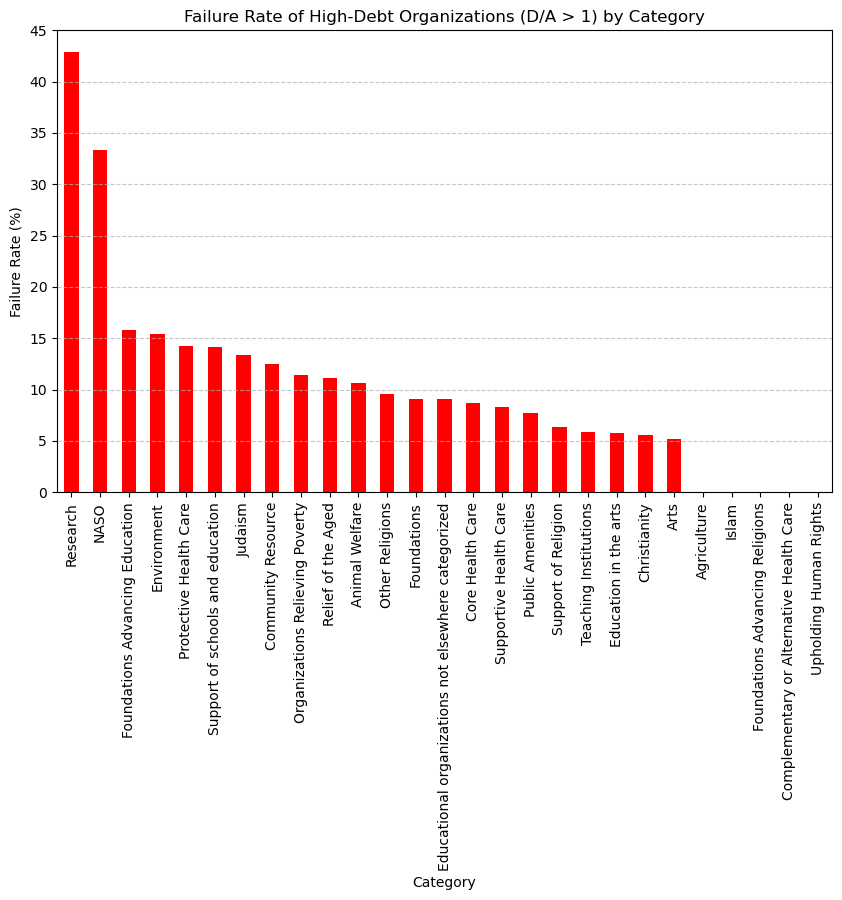

In [6]:
df.groupby([df['Class']==True])[['Debt_Ratio']].describe()


import matplotlib.pyplot as plt

df['High_Debt'] = df['Debt_Ratio']>1

high_debt = df[df['High_Debt'] == True]

failure_by_cat = high_debt.groupby('Category')['Class'].mean() * 100

failure_by_cat = failure_by_cat.sort_values(ascending=False)

ax = failure_by_cat.plot(kind='bar', figsize=(10,6), color='red')

ax.set_ylabel('Failure Rate (%)')
ax.set_title('Failure Rate of High-Debt Organizations (D/A > 1) by Category')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=90)
plt.show()



In [7]:
# INTERNAL VARIABLE
# - Designation
# - log(total revenue)
# - log(total expenditures)
# - debt ratio
# =========================

# Standardize designation
df["Designation_clean"] = (df["Designation"].astype(str).str.strip()
                        .str.replace(r"\s+", " ", regex=True)
                           .str.title())

# financial columns to numeric
numeric_cols = ["Total_Revenue", "Total_Expenditures", "Total_Assets", "Total_Liabilities"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# internal features
df["Log_Total_Revenue"] = np.log1p(df["Total_Revenue"])
df["Log_Total_Expenditures"] = np.log1p(df["Total_Expenditures"])
df["Debt_Ratio"] = df["Total_Liabilities"] / df["Total_Assets"]

# handle divide-by-zero infinities
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# cap extreme debt ratios
cap = df["Debt_Ratio"].quantile(0.99)
df["Debt_Ratio"] = df["Debt_Ratio"].clip(upper=cap)


# univariate analysis for numeric variables
designation_summary = df["Designation_clean"].value_counts().to_frame("Count")
designation_summary["Percent"] = df["Designation_clean"].value_counts(normalize=True) * 100

designation_summary



,Count,Percent
Designation_clean,,
Charitable Organization,59534,86.422692
Private Foundation,5088,7.386009
Public Foundation,4265,6.191299


In [8]:
#1: table for counts and percentages of category
#exploring the catergory variable

# 1: Prepare the table
counts = df['Category'].value_counts()
percentages = (df['Category'].value_counts(normalize=True) * 100).round(2)

# Create the DataFrame
table = pd.DataFrame({'Counts': counts, 'Percentage(%)': percentages})

# Optional: Name the index so the Excel file has a header for the first column
table.index.name = 'Category'

# 2: Export to Excel (Must include a filename in quotes)
table.to_excel("Category_Distribution.xlsx")

print("Table exported as 'Category_Distribution.xlsx'")

Table exported as 'Category_Distribution.xlsx'
